In [1]:
import os
import glob

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

from czifile import CziFile

from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment

from skimage import (
    io, filters, morphology, measure, segmentation, exposure
)
from skimage.filters import (
    threshold_otsu, threshold_sauvola, gaussian
)
from skimage.morphology import (
    remove_small_objects, h_maxima, disk, remove_small_holes
)
from skimage.feature import peak_local_max

from multiprocessing import (
    Pool, cpu_count
)

from sklearn.metrics import (
    confusion_matrix, classification_report, precision_recall_curve, auc
)

In [2]:
def mip_to_uint8(stack):
    
    mip = np.max(stack, axis=0)
    mip = mip.astype(np.float32)
    mip -= mip.min()
    if mip.max() > 0:
        mip /= mip.max()
    mip *= 255

    return mip.astype(np.uint8)

In [3]:
def load_labelstudio_annotations(json_file, image_shape, image_name):

    with open(json_file) as f:
        data = json.load(f)

    masks = []
    labels = []

    for task in data:

        task_image = task["data"]["image"]

        if image_name not in os.path.basename(task_image):
            continue

        for ann in task["annotations"]:

            for result in ann["result"]:

                if result["type"] != "polygonlabels":
                    continue

                poly = np.array(result["value"]["points"])

                # перевод процентов в пиксели
                poly[:,0] = poly[:,0] / 100 * image_shape[1]
                poly[:,1] = poly[:,1] / 100 * image_shape[0]

                mask = np.zeros(image_shape, dtype=np.uint8)

                pts = poly.astype(np.int32)
                cv2.fillPoly(mask, [pts], 1)

                masks.append(mask)

                label_name = result["value"]["polygonlabels"][0]
                labels.append(label_name)

    return masks, labels

In [4]:
def extract_predicted_nuclei(binary_mask):

    labeled = measure.label(binary_mask)

    nuclei = []

    for region in measure.regionprops(labeled):

        mask = (labeled == region.label).astype(np.uint8)
        nuclei.append(mask)

    return nuclei

In [5]:
def split_gt_by_class(gt_masks, gt_labels):

    gt_pos = []
    gt_neg = []

    for mask, label in zip(gt_masks, gt_labels):

        label = label.lower()

        if label == 'neuronal':
            gt_pos.append(mask)

        elif label == 'non-neuronal':
            gt_neg.append(mask)

        else:
            raise ValueError(f"Unknown label: {label}")

    return gt_pos, gt_neg

In [6]:
def compute_iou(mask1, mask2):

    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 0

    return intersection / union

In [7]:
def compute_iou_matrix(gt_masks, pred_masks):

    iou_matrix = np.zeros((len(gt_masks), len(pred_masks)))

    for i, gt in enumerate(gt_masks):
        for j, pred in enumerate(pred_masks):

            iou_matrix[i, j] = compute_iou(gt, pred)

    return iou_matrix

In [8]:
def hungarian_matching(gt_masks, pred_masks, iou_threshold=0.5):

    iou_matrix = compute_iou_matrix(gt_masks, pred_masks)

    cost_matrix = 1 - iou_matrix

    gt_ind, pred_ind = linear_sum_assignment(cost_matrix)

    matches = []

    for g, p in zip(gt_ind, pred_ind):

        iou = iou_matrix[g, p]

        if iou >= iou_threshold:
            matches.append((g, p, iou))

    return matches

In [9]:
def compute_overlap(mask1, mask2):

    intersection = np.logical_and(mask1, mask2).sum()

    if intersection == 0:
        return 0, 0

    union = np.logical_or(mask1, mask2).sum()

    iou = intersection / union
    overlap_pred = intersection / mask1.sum()

    return iou, overlap_pred

In [10]:
def overlaps_negative(pred_mask,
                      gt_neg_masks,
                      iou_thr=0.3,
                      overlap_thr=0.25):

    for gt in gt_neg_masks:

        iou, overlap = compute_overlap(pred_mask, gt)

        if iou > iou_thr or overlap > overlap_thr:
            return True

    return False

In [11]:
def detection_metrics(gt_pos_masks,
                      gt_neg_masks,
                      pred_masks,
                      matches):

    TP = len(matches)

    FN = len(gt_pos_masks) - TP

    matched_pred = {p for _, p, _ in matches}

    FP = 0

    for i, pred in enumerate(pred_masks):

        if i in matched_pred:
            continue

        if overlaps_negative(pred, gt_neg_masks):
            FP += 1

    precision = TP / (TP + FP) if TP + FP else 0
    recall = TP / (TP + FN) if TP + FN else 0

    F1 = 2 * precision * recall / (precision + recall) if precision + recall else 0

    return {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "F1": F1
    }

In [12]:
def compute_overlap_stats(gt_masks, pred_masks, matches):

    dice_scores = []
    iou_scores = []

    for g, p, _ in matches:

        gt = gt_masks[g]
        pred = pred_masks[p]

        intersection = np.logical_and(gt, pred).sum()

        dice = 2 * intersection / (gt.sum() + pred.sum())

        union = np.logical_or(gt, pred).sum()

        iou = intersection / union

        dice_scores.append(dice)
        iou_scores.append(iou)

    return dice_scores, iou_scores

In [13]:
def build_pr_dataset(gt_pos_masks, gt_neg_masks, pred_masks, fitc_image):

    y_true = []
    y_score = []

    # объединяем GT
    all_gt = [(mask, 1) for mask in gt_pos_masks] + \
             [(mask, 0) for mask in gt_neg_masks]

    for gt_mask, label in all_gt:

        # находим лучшее совпадение среди предсказаний
        best_score = 0

        for pred in pred_masks:

            iou = compute_iou(gt_mask, pred)

            if iou > 0.3:  # мягкий порог

                # считаем интенсивность FITC
                values = fitc_image[pred.astype(bool)]

                score = values.mean()

                if score > best_score:
                    best_score = score

        y_true.append(label)
        y_score.append(best_score)

    return np.array(y_true), np.array(y_score)

In [14]:
Images = {'Image_1':'images/HC_7/HC_7_NeuN-488_DAPI_40x_Z0,5_1.czi',
         'Image_2':'images/HC_7/HC_7_NeuN-488_DAPI_40x_Z0,5_2.czi',
         'Image_3':'images/HC_7/HC_7_NeuN-488_DAPI_40x_Z0,5_3.czi',
         'Image_4':'images/SZ_8/SZ_8_NeuN-488_DAPI_40x_Z0,5_1.czi',
         'Image_5':'images/SZ_8/SZ_8_NeuN-488_DAPI_40x_Z0,5_2.czi',
         'Image_6':'images/SZ_8/SZ_8_NeuN-488_DAPI_40x_Z0,5_3.czi',
         'Image_7':'images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_1.czi',
         'Image_8':'images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_2.czi',
         'Image_9':'images/HC_2/HC_2_NeuN-488_DAPI_40x_Z0,5_3.czi',
         'Image_10':'images/SZ_5/SZ_5_NeuN-488_DAPI_40x_Z0,5_1.czi',
         'Image_11':'images/SZ_5/SZ_5_NeuN-488_DAPI_40x_Z0,5_2.czi',
         'Image_12':'images/SZ_5/SZ_5_NeuN-488_DAPI_40x_Z0,5_3.czi',
         }

In [15]:
with open('data/LabelStudio.MannualAnnotaion.json') as f:
        data = json.load(f)

In [16]:
precision_array = []
recall_array = []
F1_array = []
Dice_array = []
IoU_array = []

y_true_AUC, y_score_AUC = np.array([]), np.array([])

image_shape = (1024,1024)


for i in range(1,7):
    
    czi_path = Images[f'Image_{i}']
        
    with CziFile(czi_path) as czi:
        data = czi.asarray()
    
    data = np.squeeze(data)
    
    ch0_stack = data[0]
    ch1_stack = data[1]
    
    dapi = mip_to_uint8(ch0_stack)
    fitc = mip_to_uint8(ch1_stack)
    
    if len(dapi.shape) == 3:
        dapi = cv2.cvtColor(dapi, cv2.COLOR_BGR2GRAY)
    
    if len(fitc.shape) == 3:
        fitc = cv2.cvtColor(fitc, cv2.COLOR_BGR2GRAY)
    
    name = os.path.splitext(os.path.basename(czi_path))[0]
    
    background = filters.gaussian(dapi, sigma=20)
    dapi_corr = exposure.rescale_intensity(dapi - background)
    
    window = 101
    sauvola_thresh = threshold_sauvola(dapi_corr, window_size=window, k=0.15)
    
    binary = dapi_corr > sauvola_thresh
    
    binary = morphology.opening(binary, disk(5))
    binary = remove_small_objects(binary, min_size=120)
    binary = remove_small_holes(binary, area_threshold=120)

    distance = ndi.distance_transform_edt(binary)
    distance = filters.gaussian(distance, sigma=2)

    coords = peak_local_max(
        distance,
        min_distance=12,
        threshold_abs=0.1,
        labels=binary
    )
    
    markers = np.zeros_like(distance, dtype=int)
    markers[tuple(coords.T)] = np.arange(1, len(coords)+1)

    labels = segmentation.watershed(
        -distance,
        markers,
        mask=binary
    )

    regions = measure.regionprops(labels, intensity_image=fitc)
    
    results = []
    for r in regions:
        results.append({
            "label": r.label,
            "area_px": r.area,
            "mean_fitc": r.mean_intensity,
            "total_int": r.mean_intensity * r.area,
            'solidity': r.solidity,
            'eccentricity': r.eccentricity
        })
    
    if len(results) == 0:
        print(f"⚠️ Нет объектов: {name}")
    
    df = pd.DataFrame(results)
    
    df = df[
        (df.solidity > 0.9) &
        (df.eccentricity < 0.85) &
        (df.area_px < 2 * df.area_px.median())
    ]

    if len(df) > 0:
        fitc_threshold = filters.threshold_otsu(df["mean_fitc"].values)
        df_filtered = df[df["mean_fitc"] > 1 * fitc_threshold]
    else:
        df_filtered = df

    final_mask = np.zeros_like(labels)
    
    for label_i in df_filtered["label"]:
        final_mask[labels == label_i] = label_i
    
    df_filtered['image'] = czi_path.split('/')[-1]
    
    print(f"Done: {name}")
    
    gt_masks, gt_labels = load_labelstudio_annotations(
        "data/LabelStudio.MannualAnnotaion.json",
        image_shape,
        f'Image_{i}'    
    )
    
    gt_pos_masks, gt_neg_masks = split_gt_by_class(
        gt_masks,
        gt_labels
    )
    
    pred_binary = final_mask > 1
    
    pred_masks =  extract_predicted_nuclei(pred_binary)
    
    iou_threshold = 0.5
    
    matches = hungarian_matching(
        gt_pos_masks,
        pred_masks,
        iou_threshold
    )
    
    metrics = detection_metrics(
        gt_pos_masks,
        gt_neg_masks,
        pred_masks,
        matches
    )
    
    print(metrics)
    
    dice_scores, iou_scores = compute_overlap_stats(
        gt_pos_masks,
        pred_masks,
        matches
    )
    
    print("Mean Dice:", np.mean(dice_scores))
    print("Mean IoU:", np.mean(iou_scores))


    precision_array.append(metrics['precision'])
    recall_array.append(metrics['recall'])
    F1_array.append(metrics['F1'])
    Dice_array += dice_scores
    IoU_array += iou_scores


    y_true, y_score = build_pr_dataset(
        gt_pos_masks,
        gt_neg_masks,
        pred_masks,
        fitc
    )

    y_true_AUC = np.concatenate([y_true_AUC, y_true])
    y_score_AUC = np.concatenate([y_score_AUC, y_score])

/tmp/ipykernel_2538175/478911106.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


Done: HC_7_NeuN-488_DAPI_40x_Z0,5_1
{'TP': 23, 'FP': 1, 'FN': 125, 'precision': 0.9583333333333334, 'recall': 0.1554054054054054, 'F1': 0.26744186046511625}
Mean Dice: 0.8588715691966179
Mean IoU: 0.7602526285160335


/tmp/ipykernel_2538175/478911106.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


Done: HC_7_NeuN-488_DAPI_40x_Z0,5_2
{'TP': 14, 'FP': 1, 'FN': 21, 'precision': 0.9333333333333333, 'recall': 0.4, 'F1': 0.5599999999999999}
Mean Dice: 0.8638461281887527
Mean IoU: 0.7639663941447946


/tmp/ipykernel_2538175/478911106.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


...

Done: SZ_8_NeuN-488_DAPI_40x_Z0,5_1
{'TP': 26, 'FP': 9, 'FN': 40, 'precision': 0.7428571428571429, 'recall': 0.3939393939393939, 'F1': 0.5148514851485148}
Mean Dice: 0.8964737145506951
Mean IoU: 0.8166166725550977


/tmp/ipykernel_2538175/478911106.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


Done: SZ_8_NeuN-488_DAPI_40x_Z0,5_2
{'TP': 6, 'FP': 0, 'FN': 19, 'precision': 1.0, 'recall': 0.24, 'F1': 0.3870967741935484}
Mean Dice: 0.8292016716852536
Mean IoU: 0.7119945073826072


/tmp/ipykernel_2538175/478911106.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['image'] = czi_path.split('/')[-1]


Done: SZ_8_NeuN-488_DAPI_40x_Z0,5_3
{'TP': 8, 'FP': 0, 'FN': 15, 'precision': 1.0, 'recall': 0.34782608695652173, 'F1': 0.5161290322580645}
Mean Dice: 0.9025472696137894
Mean IoU: 0.8238523069646111


/tmp/ipykernel_2538175/4208331715.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Precision'])
/tmp/ipykernel_2538175/4208331715.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Recall'])
/tmp/ipykernel_2538175/4208331715.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Dice'])
/tmp/ipykernel_2538175/4208331715.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['IoU'])


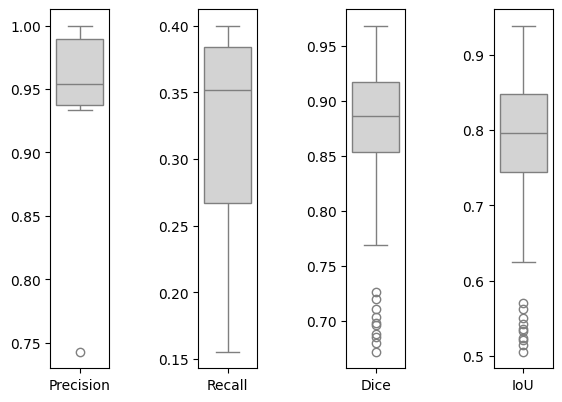

In [17]:
f, axs = plt.subplots(nrows=1, ncols=4)

ax = axs[0]
sns.boxplot(precision_array, ax=ax, color='lightgrey')
ax.set_xticklabels(['Precision'])

ax = axs[1]
sns.boxplot(recall_array, ax=ax, color='lightgrey')
ax.set_xticklabels(['Recall'])

ax = axs[2]
sns.boxplot(Dice_array, ax=ax, color='lightgrey')
ax.set_xticklabels(['Dice'])

ax = axs[3]
sns.boxplot(IoU_array, ax=ax, color='lightgrey')
ax.set_xticklabels(['IoU'])

plt.tight_layout(pad=3.50)
plt.show()

In [18]:
precision_PR, recall_PR, thresholds = precision_recall_curve(y_true_AUC, y_score_AUC)
    
pr_auc = auc(recall_PR, precision_PR)

print("PR-AUC:", pr_auc)

PR-AUC: 0.7116333960622563


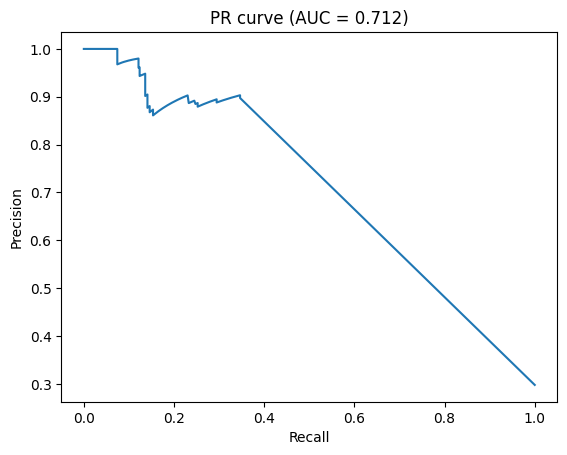

In [19]:
import matplotlib.pyplot as plt

plt.plot(recall_PR, precision_PR)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR curve (AUC = {pr_auc:.3f})")
plt.show()